In [1]:
using FFTW
using GLMakie

In [2]:
function read_test(file)
    vals = map(x -> parse(Int32,x[1]) + 1im*parse(Int32,x[2]),split.(readlines(file),", "))
    return vals
end

read_test (generic function with 1 method)

In [3]:
function bin_map(k0, M, P, N)
    k_first = k0 - 1
    k_last = k0 + M + P
    bin_map = zeros(Int8,N)
    pilots = floor.(Int,(k_first.+((1:P)*(k_last-k_first))/(P+1)))
    bin_map[(k_first+1):(k_last+1)] .= 1
    bin_map[pilots.+1] .= 2
    bin_map[k_first+1] = 2
    bin_map[k_last+1] = 2
    return bin_map
end

bin_map (generic function with 1 method)

In [4]:
k0 = 22;
M = 256;
P = 8;
CP = 8;
N = 1024;

In [5]:
ramp_cp = read_test("../SC_FDMA_SDR/ramp_out.txt");
ramp = ramp_cp[CP+1:end];
ramp_fft = fft(ramp);

In [6]:
bins = bin_map(k0,M,P,N)
slope = 262143
expected = zeros(N)
cnt = 0
for i in 1:N
    if bins[i] == 0
        expected[i] = 0
    elseif bins[i] == 1
        expected[i] = cnt*slope
        cnt = cnt + 1
    else
        expected[i] = 759250125
    end
end
expected_C = expected + 1im*expected;
expected_C[bins.==1]=fft(expected_C[bins.==1])/16

256-element Vector{ComplexF64}:
           5.3477172e8 + 5.3477172e8im
 -1.7297923229971707e8 + 1.6878494429971707e8im
  -8.752531958943628e7 + 8.333103158943628e7im
  -5.903496151054814e7 + 5.484067351054813e7im
  -4.478549079693613e7 + 4.059120279693613e7im
  -3.623237358113078e7 + 3.203808558113078e7im
 -3.0527431561583936e7 + 2.6333143561583936e7im
 -2.6450016597865768e7 + 2.225572859786574e7im
 -2.3389804359351598e7 + 1.9195516359351594e7im
  -2.100772554135056e7 + 1.681343754135058e7im
 -1.9100338351466205e7 + 1.4906050351466205e7im
  -1.753817963967729e7 + 1.3343891639677292e7im
 -1.6234940463301612e7 + 1.204065246330161e7im
                       ⋮
  1.2040652463301612e7 - 1.623494046330161e7im
   1.334389163967729e7 - 1.7538179639677294e7im
  1.4906050351466205e7 - 1.910033835146621e7im
   1.681343754135058e7 - 2.100772554135056e7im
  1.9195516359351598e7 - 2.3389804359351598e7im
  2.2255728597865745e7 - 2.645001659786577e7im
  2.6333143561583936e7 - 3.052743156158393e7im
   3

In [7]:
EVM(X,X_hat) = sqrt(sum(abs2.(X-X_hat))/(sum(abs2.(X))))
gain(X,X_hat) = sum(conj.(X_hat).*X)/(sum(abs2.(X)))
EVM_g(X,X_hat) = sqrt(sum(abs2.(X-(gain(X,X_hat)*X_hat)))/(sum(abs2.(X_hat))))

EVM_g (generic function with 1 method)

In [8]:
data_ramp = ifft(ramp_fft[bins.==1])*16
data_expected = collect((1:M)*slope+1im*(1:M)*slope);

In [9]:
dB(x)=20*log10(x)
EVM_full = EVM(expected_C,ramp_fft)
EVM_pilots = EVM(expected_C[bins.==2],ramp_fft[bins.==2])
EVM_data_fft = EVM(expected_C[bins.==1],ramp_fft[bins.==1])
EVM_active = EVM(expected_C[bins.>0],ramp_fft[bins.>0])
EVM_data_ifft = EVM(data_expected,data_ramp)
leak_ratio = sqrt(sum(abs2.(ramp_fft[bins.==0])) / sum(abs2.(ramp_fft[bins.>0])))

1.739577037047126e-5

In [10]:
dB(EVM_full),dB(EVM_data_fft),dB(EVM_pilots),dB(leak_ratio)

(-77.59845117672823, -71.8532274810467, -78.57351012148521, -95.19112667579675)

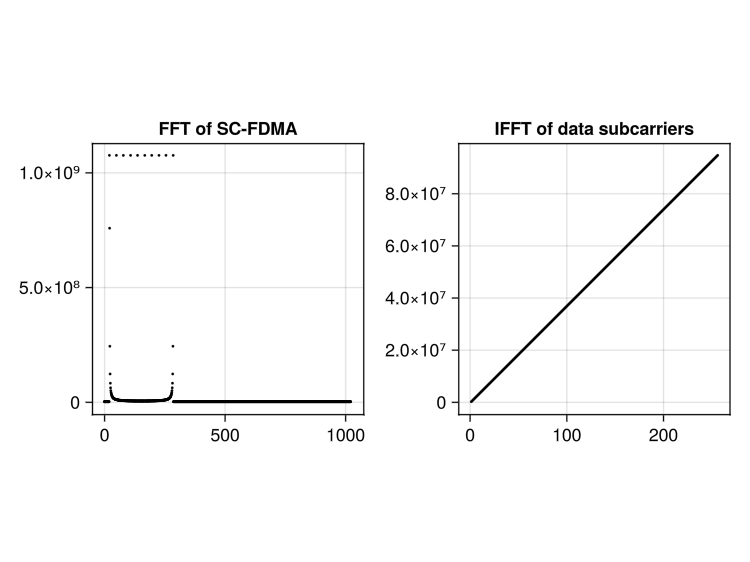

In [11]:
fig = Figure()
ax = Axis(fig[1,1],title="FFT of SC-FDMA",aspect=AxisAspect(1))
scatter!(ax,abs.(ramp_fft),markersize=3,color=:black)
ax = Axis(fig[1,2],title="IFFT of data subcarriers",aspect=AxisAspect(1))
scatter!(ax,abs.(data_ramp),markersize=3,color=:black)
fig

